<a href="https://colab.research.google.com/github/bharath-hue/TASK_TNS_AIML/blob/main/Presentation%20Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files

files.upload()

df = pd.read_csv("Presentation-TASK - Sheet1.csv")

df_copy = df.copy()

df_copy = df_copy.rename(columns={
    'Technical knowledge': 'Technical',
    'Attrire': 'Attire'
})

for col in ['Technical', 'Communication', 'Attire']:
    df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce')

df_clean = df_copy.dropna(
    subset=['Participant Name', 'Technical', 'Communication', 'Attire']
).copy()

df_clean['Total Marks'] = (
    df_clean['Technical'] +
    df_clean['Communication'] +
    df_clean['Attire']
)

top_total = df_clean.nlargest(5, 'Total Marks')[['Participant Name', 'Total Marks']]
top_technical = df_clean.nlargest(5, 'Technical')[['Participant Name', 'Technical']]
top_communication = df_clean.nlargest(5, 'Communication')[['Participant Name', 'Communication']]
top_attire = df_clean.nlargest(5, 'Attire')[['Participant Name', 'Attire']]

print("\nTOP 5 STUDENTS - TOTAL MARKS")
print(top_total)

print("\nTOP 5 STUDENTS - TECHNICAL")
print(top_technical)

print("\nTOP 5 STUDENTS - COMMUNICATION")
print(top_communication)

print("\nTOP 5 STUDENTS - ATTIRE")
print(top_attire)

output_file = "Presentation_Task_Report.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_clean.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    top_total.to_excel(writer, sheet_name="Top_Total", index=False)
    top_technical.to_excel(writer, sheet_name="Top_Technical", index=False)
    top_communication.to_excel(writer, sheet_name="Top_Communication", index=False)
    top_attire.to_excel(writer, sheet_name="Top_Attire", index=False)

files.download(output_file)

Saving Presentation-TASK - Sheet1.csv to Presentation-TASK - Sheet1 (1).csv

TOP 5 STUDENTS - TOTAL MARKS
        Participant Name  Total Marks
7       BOPPANI BHARGAVI         19.0
65       Gajula Sathvika         19.0
22   Madipadiga Kousheel         18.0
23       Kanigiri Devika         18.0
29  Mohammed Masoom Baba         18.0

TOP 5 STUDENTS - TECHNICAL
                     Participant Name  Technical
7                    BOPPANI BHARGAVI        8.0
45  SRI SAI MADHURVIND MUDUTHANAPELLY        8.0
65                    Gajula Sathvika        8.0
8                AjithReddy Anumandla        7.0
19                  Rathakanti Rohith        7.0

TOP 5 STUDENTS - COMMUNICATION
                Participant Name  Communication
4          Akhil Reddy Komireddy            7.0
5                   CHARAN KONDA            7.0
7               BOPPANI BHARGAVI            7.0
18  PEETHALA JYOTHI SWAROOP BABU            7.0
22           Madipadiga Kousheel            7.0

TOP 5 STUDENTS - ATTIRE

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

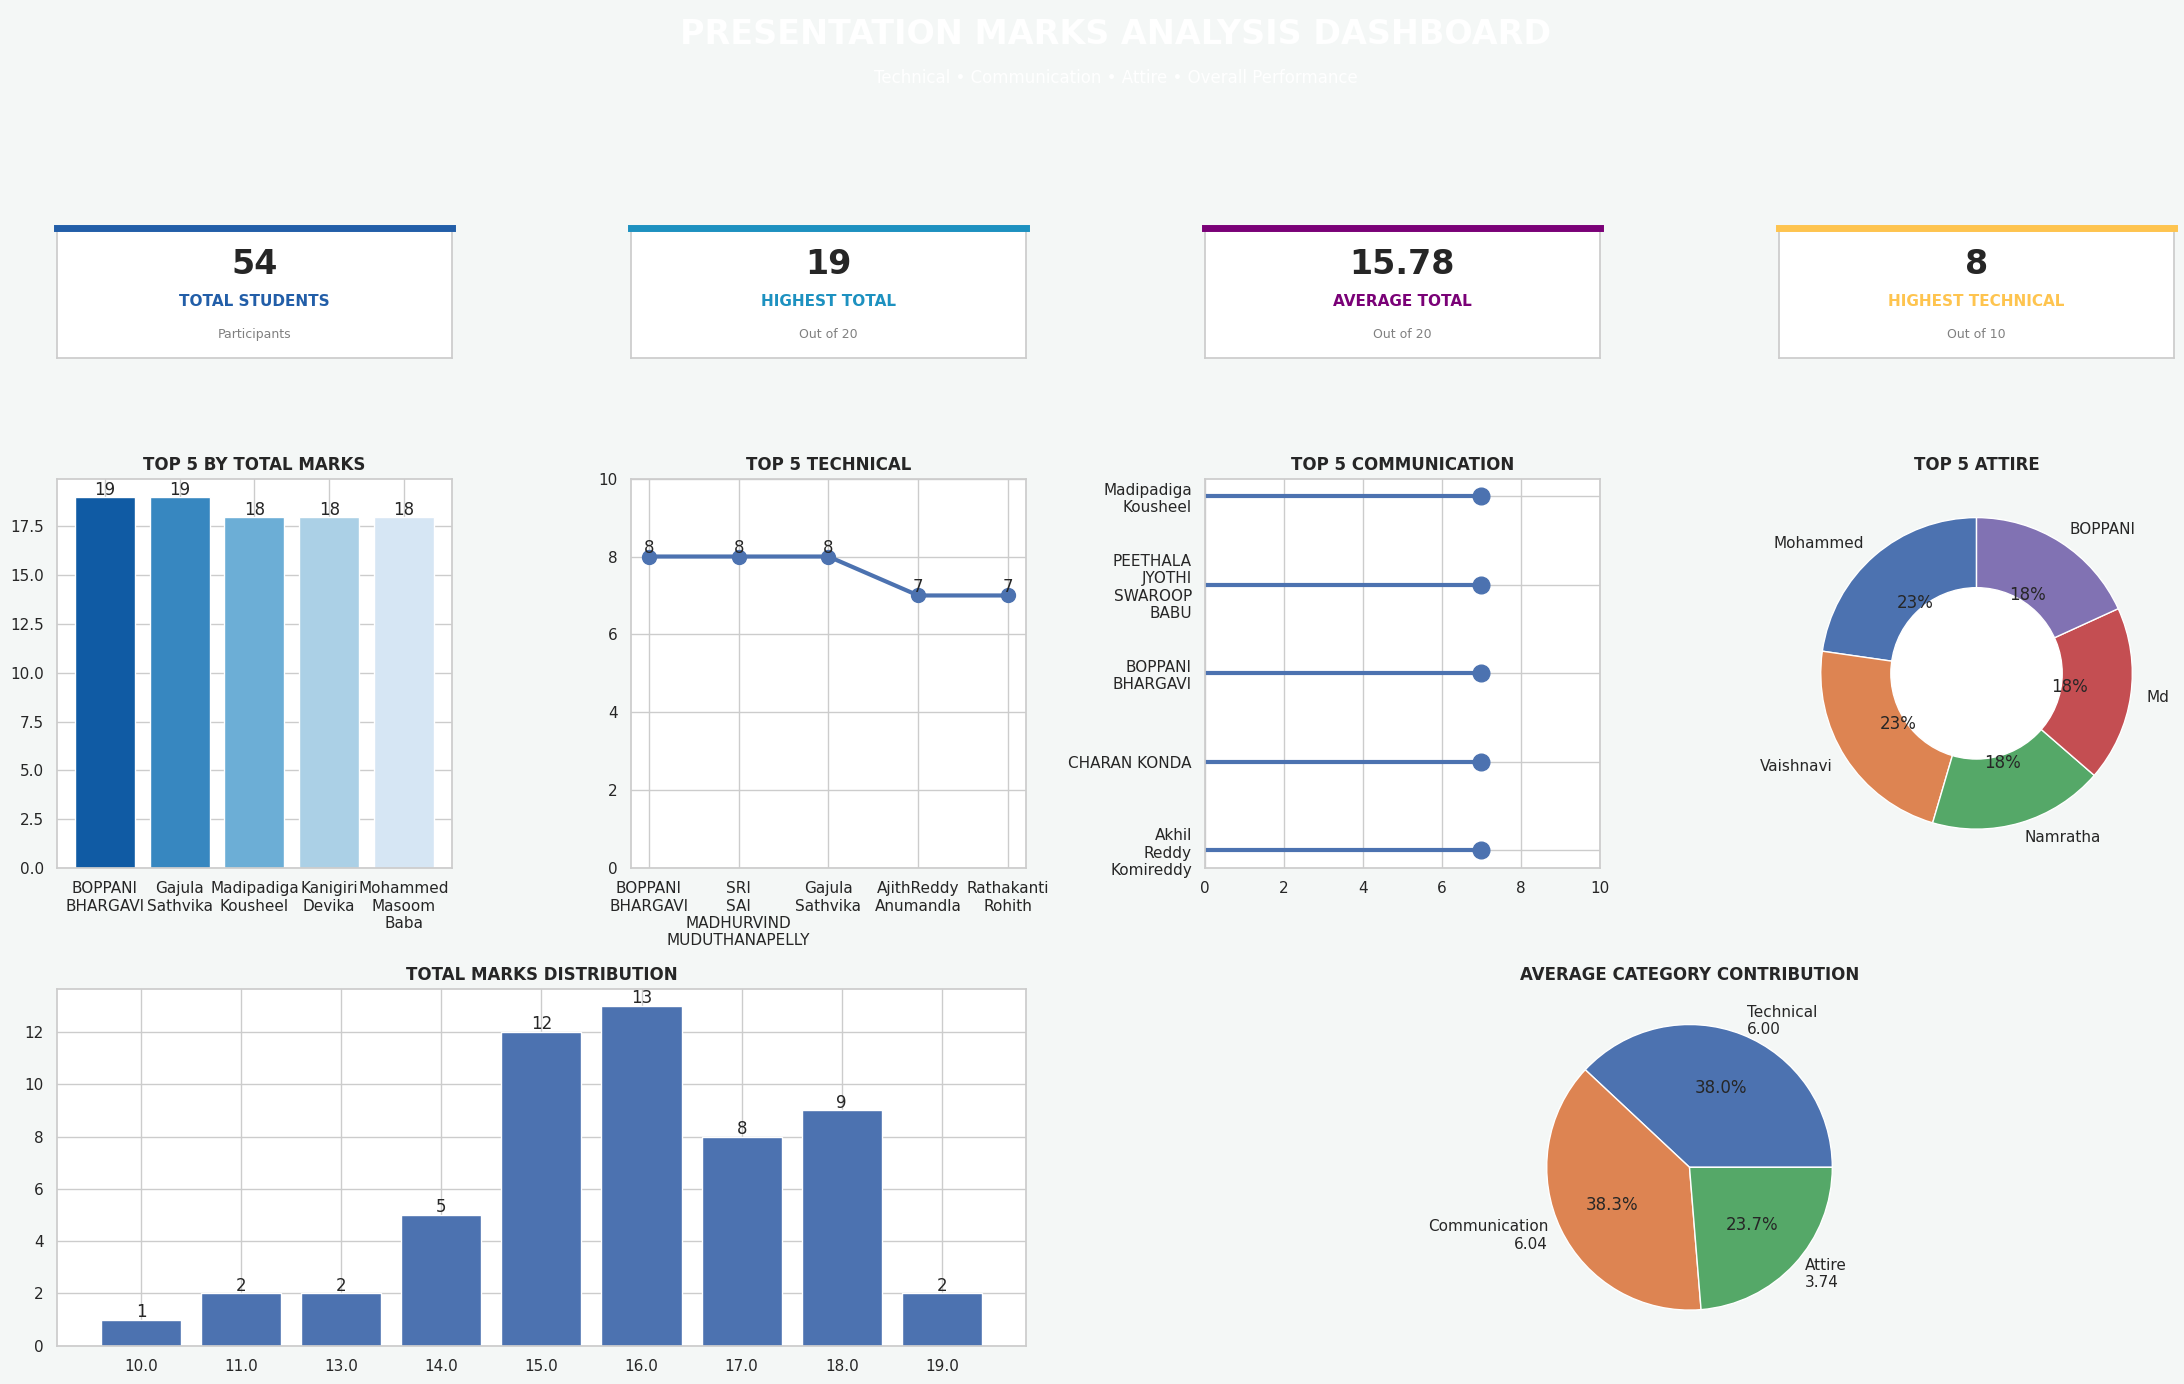

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

top_total = df_clean.nlargest(
    5,
    "Total Marks"
)[["Participant Name", "Total Marks"]]

top_technical = df_clean.nlargest(
    5,
    "Technical"
)[["Participant Name", "Technical"]]

top_communication = df_clean.nlargest(
    5,
    "Communication"
)[["Participant Name", "Communication"]]

top_attire = df_clean.nlargest(
    5,
    "Attire"
)[["Participant Name", "Attire"]]

total_students = len(df_clean)
highest_total = int(df_clean["Total Marks"].max())
highest_technical = int(df_clean["Technical"].max())
average_total = round(df_clean["Total Marks"].mean(), 2)

sns.set_theme(style="whitegrid")

def wrap_labels(names):
    return [
        str(x).replace(" ", "\n")
        if len(str(x)) > 12
        else str(x)
        for x in names
    ]

fig = plt.figure(figsize=(22, 14), facecolor="#F4F7F6")

gs = gridspec.GridSpec(
    4,
    4,
    figure=fig,
    height_ratios=[0.3, 0.4, 1.2, 1.1]
)

ax_header = fig.add_subplot(gs[0, :])

ax_header.set_facecolor("#0F4C81")

ax_header.text(
    0.5,
    0.65,
    "PRESENTATION MARKS ANALYSIS DASHBOARD",
    fontsize=24,
    color="white",
    weight="bold",
    ha="center"
)

ax_header.text(
    0.5,
    0.25,
    "Technical • Communication • Attire • Overall Performance",
    fontsize=12,
    color="white",
    ha="center"
)

ax_header.axis("off")

def create_kpi(ax, title, value, subtitle, color):
    ax.set_facecolor("white")

    ax.spines["top"].set_color(color)
    ax.spines["top"].set_linewidth(5)

    ax.text(
        0.5,
        0.65,
        value,
        fontsize=24,
        weight="bold",
        ha="center"
    )

    ax.text(
        0.5,
        0.40,
        title,
        fontsize=11,
        color=color,
        weight="bold",
        ha="center"
    )

    ax.text(
        0.5,
        0.15,
        subtitle,
        fontsize=9,
        color="gray",
        ha="center"
    )

    ax.set_xticks([])
    ax.set_yticks([])

create_kpi(
    fig.add_subplot(gs[1, 0]),
    "TOTAL STUDENTS",
    str(total_students),
    "Participants",
    "#225EA8"
)

create_kpi(
    fig.add_subplot(gs[1, 1]),
    "HIGHEST TOTAL",
    str(highest_total),
    "Out of 20",
    "#1D91C0"
)

create_kpi(
    fig.add_subplot(gs[1, 2]),
    "AVERAGE TOTAL",
    str(average_total),
    "Out of 20",
    "#7A0177"
)

create_kpi(
    fig.add_subplot(gs[1, 3]),
    "HIGHEST TECHNICAL",
    str(highest_technical),
    "Out of 10",
    "#FEC44F"
)

ax1 = fig.add_subplot(gs[2, 0])

bars = ax1.bar(
    wrap_labels(top_total["Participant Name"]),
    top_total["Total Marks"],
    color=sns.color_palette("Blues_r", 5)
)

ax1.set_title("TOP 5 BY TOTAL MARKS", weight="bold")

for b in bars:
    ax1.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.1,
        int(b.get_height()),
        ha="center"
    )

ax2 = fig.add_subplot(gs[2, 1])

ax2.plot(
    wrap_labels(top_technical["Participant Name"]),
    top_technical["Technical"],
    marker="o",
    linewidth=3,
    markersize=10
)

for i, v in enumerate(top_technical["Technical"]):
    ax2.text(i, v + 0.1, int(v), ha="center")

ax2.set_ylim(0, 10)

ax2.set_title(
    "TOP 5 TECHNICAL",
    weight="bold"
)

ax3 = fig.add_subplot(gs[2, 2])

names = wrap_labels(
    top_communication["Participant Name"]
)

scores = list(
    top_communication["Communication"]
)

y = range(len(names))

ax3.hlines(
    y=y,
    xmin=0,
    xmax=scores,
    linewidth=3
)

ax3.plot(
    scores,
    y,
    "o",
    markersize=12
)

ax3.set_yticks(list(y))
ax3.set_yticklabels(names)

ax3.set_xlim(0, 10)

ax3.set_title(
    "TOP 5 COMMUNICATION",
    weight="bold"
)

ax4 = fig.add_subplot(gs[2, 3])

ax4.pie(
    top_attire["Attire"],
    labels=[
        str(x).split()[0]
        for x in top_attire["Participant Name"]
    ],
    autopct="%1.0f%%",
    startangle=90
)

centre = plt.Circle((0, 0), 0.55, color="white")
ax4.add_artist(centre)

ax4.set_title(
    "TOP 5 ATTIRE",
    weight="bold"
)

ax5 = fig.add_subplot(gs[3, :2])

dist = (
    df_clean["Total Marks"]
    .value_counts()
    .sort_index()
)

bars = ax5.bar(
    dist.index.astype(str),
    dist.values
)

ax5.set_title(
    "TOTAL MARKS DISTRIBUTION",
    weight="bold"
)

for b in bars:
    ax5.text(
        b.get_x()+b.get_width()/2,
        b.get_height()+0.1,
        int(b.get_height()),
        ha="center"
    )

ax6 = fig.add_subplot(gs[3, 2:])

avg_tech = df_clean["Technical"].mean()
avg_comm = df_clean["Communication"].mean()
avg_attire = df_clean["Attire"].mean()

ax6.pie(
    [avg_tech, avg_comm, avg_attire],
    labels=[
        f"Technical\n{avg_tech:.2f}",
        f"Communication\n{avg_comm:.2f}",
        f"Attire\n{avg_attire:.2f}"
    ],
    autopct="%1.1f%%"
)

ax6.set_title(
    "AVERAGE CATEGORY CONTRIBUTION",
    weight="bold"
)

plt.tight_layout()
plt.show()